# Paired Awake-Drowsy metrics: 60-s Processed PPG

One publication-ready figure is generated from the existing paired-value CSV files for Prediction, RQA, and LLE. No statistical tables or derived data files are created.

In [1]:
from pathlib import Path
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd

def find_phase1_root(start=Path.cwd()):
    start = start.resolve()
    for base in (start, *start.parents):
        candidate = base if base.name == "phase1" else base / "phase1"
        if (candidate / "outputs").is_dir() and (candidate / "main").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the phase1 directory.")

PHASE1 = find_phase1_root()
OUTPUTS = PHASE1 / "outputs"
FINAL = OUTPUTS / "final"
FINAL.mkdir(parents=True, exist_ok=True)
PDF_PATH = FINAL / "paired_awake_drowsy_7metrics_final.pdf"
PNG_PATH = FINAL / "paired_awake_drowsy_7metrics_final.png"

PREDICTION_FILE = OUTPUTS / "prediction" / "prediction_state_paired_values_60s_processed.csv"
RQA_FILE = OUTPUTS / "rqa" / "rqa_state_paired_values_60s_processed.csv"
LLE_FILE = OUTPUTS / "lle" / "lle_session_paired_deltas_60s_processed.csv"
for path in (PREDICTION_FILE, RQA_FILE, LLE_FILE):
    if not path.is_file():
        raise FileNotFoundError(path)

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.titlesize": 10.5,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

In [2]:
prediction = pd.read_csv(PREDICTION_FILE)
rqa = pd.read_csv(RQA_FILE)
lle = pd.read_csv(LLE_FILE)

required_prediction = {"session", "mean_cc_awake", "mean_cc_drowsy", "mean_nrmse_awake", "mean_nrmse_drowsy"}
required_rqa = {"session", "representation", "window_size", "DET_awake", "DET_drowsy",
                "Lmean_awake", "Lmean_drowsy", "LAM_awake", "LAM_drowsy", "TT_awake", "TT_drowsy"}
required_lle = {"session", "representation", "window_size_s", "lle_awake", "lle_drowsy"}
for frame, required, path in ((prediction, required_prediction, PREDICTION_FILE),
                              (rqa, required_rqa, RQA_FILE),
                              (lle, required_lle, LLE_FILE)):
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f"{path.name} is missing columns: {missing}")

rqa = rqa.loc[rqa["representation"].str.casefold().eq("processed") & rqa["window_size"].eq(60)].copy()
lle = lle.loc[lle["representation"].str.casefold().eq("processed") & lle["window_size_s"].eq(60)].copy()

def session_number(value):
    match = re.search(r"(\d+)", str(value))
    if match is None:
        raise ValueError(f"Cannot parse session number from {value!r}")
    return int(match.group(1))

for frame in (prediction, rqa, lle):
    frame["_session_number"] = frame["session"].map(session_number)
    frame.sort_values("_session_number", inplace=True)
    frame.reset_index(drop=True, inplace=True)
    if len(frame) != 20 or frame["_session_number"].nunique() != 20:
        raise ValueError("Each paired input must contain exactly 20 unique sessions.")

metric_specs = [
    (prediction, "mean_cc_awake", "mean_cc_drowsy", "CC", "CC"),
    (prediction, "mean_nrmse_awake", "mean_nrmse_drowsy", "NRMSE", "NRMSE"),
    (rqa, "DET_awake", "DET_drowsy", "DET", "DET"),
    (rqa, "Lmean_awake", "Lmean_drowsy", "Lmean", "Lmean"),
    (rqa, "LAM_awake", "LAM_drowsy", "LAM", "LAM"),
    (rqa, "TT_awake", "TT_drowsy", "TT", "TT"),
    (lle, "lle_awake", "lle_drowsy", "LLE", r"LLE (s$^{-1}$)"),
]
for frame, awake_col, drowsy_col, _, _ in metric_specs:
    values = frame[[awake_col, drowsy_col]].to_numpy(dtype=float)
    if not np.isfinite(values).all():
        raise ValueError(f"Non-finite paired values in {awake_col}/{drowsy_col}")

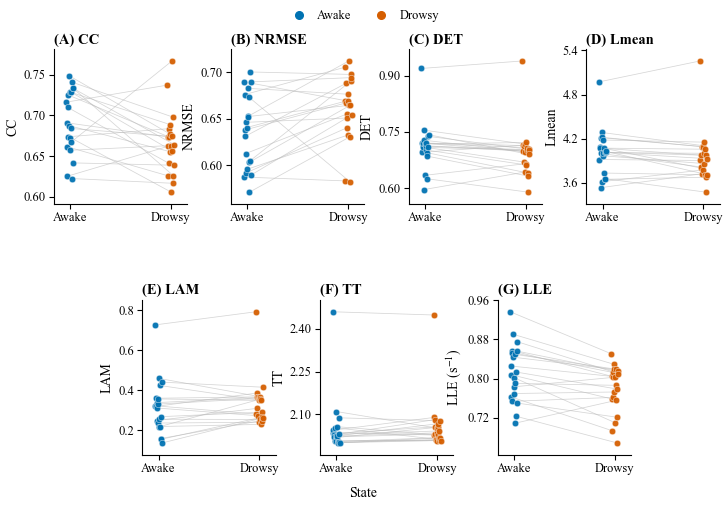

In [3]:
awake_color = "#0072B2"
drowsy_color = "#D55E00"
line_color = "#B8B8B8"
panel_labels = list("ABCDEFG")

fig = plt.figure(figsize=(7.2, 5.2), facecolor="white")
grid = fig.add_gridspec(2, 8, left=0.070, right=0.995, bottom=0.115, top=0.895, wspace=1.00, hspace=0.62)
axes = [
    fig.add_subplot(grid[0, 0:2]), fig.add_subplot(grid[0, 2:4]),
    fig.add_subplot(grid[0, 4:6]), fig.add_subplot(grid[0, 6:8]),
    fig.add_subplot(grid[1, 1:3]), fig.add_subplot(grid[1, 3:5]),
    fig.add_subplot(grid[1, 5:7]),
]

for ax, spec, panel_label in zip(axes, metric_specs, panel_labels):
    frame, awake_col, drowsy_col, title, ylabel = spec
    awake = frame[awake_col].to_numpy(dtype=float)
    drowsy = frame[drowsy_col].to_numpy(dtype=float)
    n = len(frame)
    jitter = np.linspace(-0.035, 0.035, n)

    for offset, y_awake, y_drowsy in zip(jitter, awake, drowsy):
        ax.plot([offset, 1.0 + offset], [y_awake, y_drowsy], color=line_color,
                linewidth=0.55, alpha=0.58, zorder=1)
    ax.scatter(jitter, awake, s=22, color=awake_color, edgecolor="white", linewidth=0.30, alpha=0.94, zorder=3)
    ax.scatter(1.0 + jitter, drowsy, s=22, color=drowsy_color, edgecolor="white", linewidth=0.30, alpha=0.94, zorder=3)

    all_values = np.concatenate([awake, drowsy])
    value_range = float(np.ptp(all_values))
    padding = max(value_range * 0.09, abs(float(np.mean(all_values))) * 0.015, 1e-3)
    ax.set_ylim(float(all_values.min()) - padding, float(all_values.max()) + padding)
    ax.set_xlim(-0.16, 1.16)
    ax.set_xticks([0, 1], ["Awake", "Drowsy"])
    ax.set_ylabel(ylabel, labelpad=3)
    ax.set_title(f"({panel_label}) {title}", loc="left", pad=4, fontweight="bold")
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune=None))
    ax.tick_params(direction="out", pad=2.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_handles = [
    # Line2D([0], [0], color=line_color, marker="o", markerfacecolor="#777777",
    #        markeredgecolor="white", linewidth=0.8, markersize=5.2, label="Paired sessions"),
    Line2D([0], [0], linestyle="none", marker="o", color=awake_color, markersize=5.5, label="Awake"),
    Line2D([0], [0], linestyle="none", marker="o", color=drowsy_color, markersize=5.5, label="Drowsy"),
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.992), ncol=3,
           frameon=False, handlelength=1.8, columnspacing=1.5, handletextpad=0.55)
fig.supxlabel("State", fontsize=10, y=0.028)
fig.savefig(PDF_PATH, format="pdf", bbox_inches="tight")
fig.savefig(PNG_PATH, format="png", dpi=300, bbox_inches="tight")
plt.show()